# Laboratorium 3 – Klasyfikacja: Indukcja drzew decyzyjnych za pomocą CART

## 0. Import bibliotek

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, KFold, learning_curve, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, make_scorer,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

### 1.1 Zbiór GLASS

In [5]:
from ucimlrepo import fetch_ucirepo

glass_repo = fetch_ucirepo(id=42)
X_glass = glass_repo.data.features
y_glass = glass_repo.data.targets.iloc[:, 0].rename('class')

class_names_glass = {
    1:'building_float', 
    2:'building_non_float', 
    3:'vehicle_float',
    5:'vehicle_non_float', 
    6:'containers', 
    7:'tableware'
}
target_names_glass = [class_names_glass[k] for k in sorted(y_glass.unique())]

print(f'Kształt danych: {X_glass.shape}')
print(f'Klasy: {target_names_glass}')
print(f'Rozkład klas:\n{y_glass.value_counts().sort_index()}')
X_glass.describe().T


Kształt danych: (214, 9)
Klasy: ['building_float', 'building_non_float', 'vehicle_float', 'vehicle_non_float', 'containers', 'tableware']
Rozkład klas:
class
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518365,0.003037,1.51115,1.516522,1.51768,1.519157,1.53393
Na,214.0,13.407850,0.816604,10.73000,12.907500,13.30000,13.825000,17.38000
Mg,214.0,2.684533,1.442408,0.00000,2.115000,3.48000,3.600000,4.49000
Al,214.0,1.444907,0.499270,0.29000,1.190000,1.36000,1.630000,3.50000
Si,214.0,72.650935,0.774546,69.81000,72.280000,72.79000,73.087500,75.41000
K,214.0,0.497056,0.652192,0.00000,0.122500,0.55500,0.610000,6.21000
Ca,214.0,8.956963,1.423153,5.43000,8.240000,8.60000,9.172500,16.19000
Ba,214.0,0.175047,0.497219,0.00000,0.000000,0.00000,0.000000,3.15000
Fe,214.0,0.057009,0.097439,0.00000,0.000000,0.00000,0.100000,0.51000


### 1.2 Zbiór Polish Companies Bankruptcy (PCB)

Wczytujemy oryginalny zbiór z UCI ML Repository (id=365). Zawiera dane finansowe polskich firm z lat 2000–2012 – silnie niezbalansowane klasy i brakujące wartości.

In [6]:
from ucimlrepo import fetch_ucirepo

polish_companies_bankruptcy = fetch_ucirepo(id=365)

X_pcb_df = polish_companies_bankruptcy.data.features
y_pcb_s  = polish_companies_bankruptcy.data.targets.squeeze().rename('bankrupt')


class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.k * IQR
        self.upper_ = Q3 + self.k * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)


preprocessor = Pipeline([
    ('median_imputer', SimpleImputer(strategy='median')),
    ('iqr_clipper',    IQRClipper(k=1.5)),
    ('scaler',         StandardScaler()),
])

X_pcb_imp = preprocessor.fit_transform(X_pcb_df)
X_pcb_imp = pd.DataFrame(X_pcb_imp, columns=X_pcb_df.columns)
pct = y_pcb_s.sum() / len(y_pcb_s) * 100

---
## 2. Domyślne drzewo decyzyjne – GLASS

In [7]:
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_glass, y_glass, test_size=0.25, stratify=y_glass
)

dt_default = DecisionTreeClassifier()
dt_default.fit(X_tr_g, y_tr_g)
y_pred_default = dt_default.predict(X_te_g)

print('=== Domyślne drzewo CART – GLASS ===')
print(f'Głębokość: {dt_default.get_depth()}')
print(f'Liczba liści: {dt_default.get_n_leaves()}')
print(f'Balanced accuracy (test): {balanced_accuracy_score(y_te_g, y_pred_default):.4f}')
print(f'Balanced accuracy (train): {balanced_accuracy_score(y_tr_g, dt_default.predict(X_tr_g)):.4f}')
print()
print(classification_report(y_te_g, y_pred_default,
                             target_names=target_names_glass))


=== Domyślne drzewo CART – GLASS ===
Głębokość: 10
Liczba liści: 45
Balanced accuracy (test): 0.6557
Balanced accuracy (train): 1.0000

                    precision    recall  f1-score   support

    building_float       0.79      0.83      0.81        18
building_non_float       0.76      0.68      0.72        19
     vehicle_float       0.60      0.75      0.67         4
 vehicle_non_float       0.67      0.67      0.67         3
        containers       0.00      0.00      0.00         2
         tableware       0.89      1.00      0.94         8

          accuracy                           0.76        54
         macro avg       0.62      0.66      0.63        54
      weighted avg       0.75      0.76      0.75        54



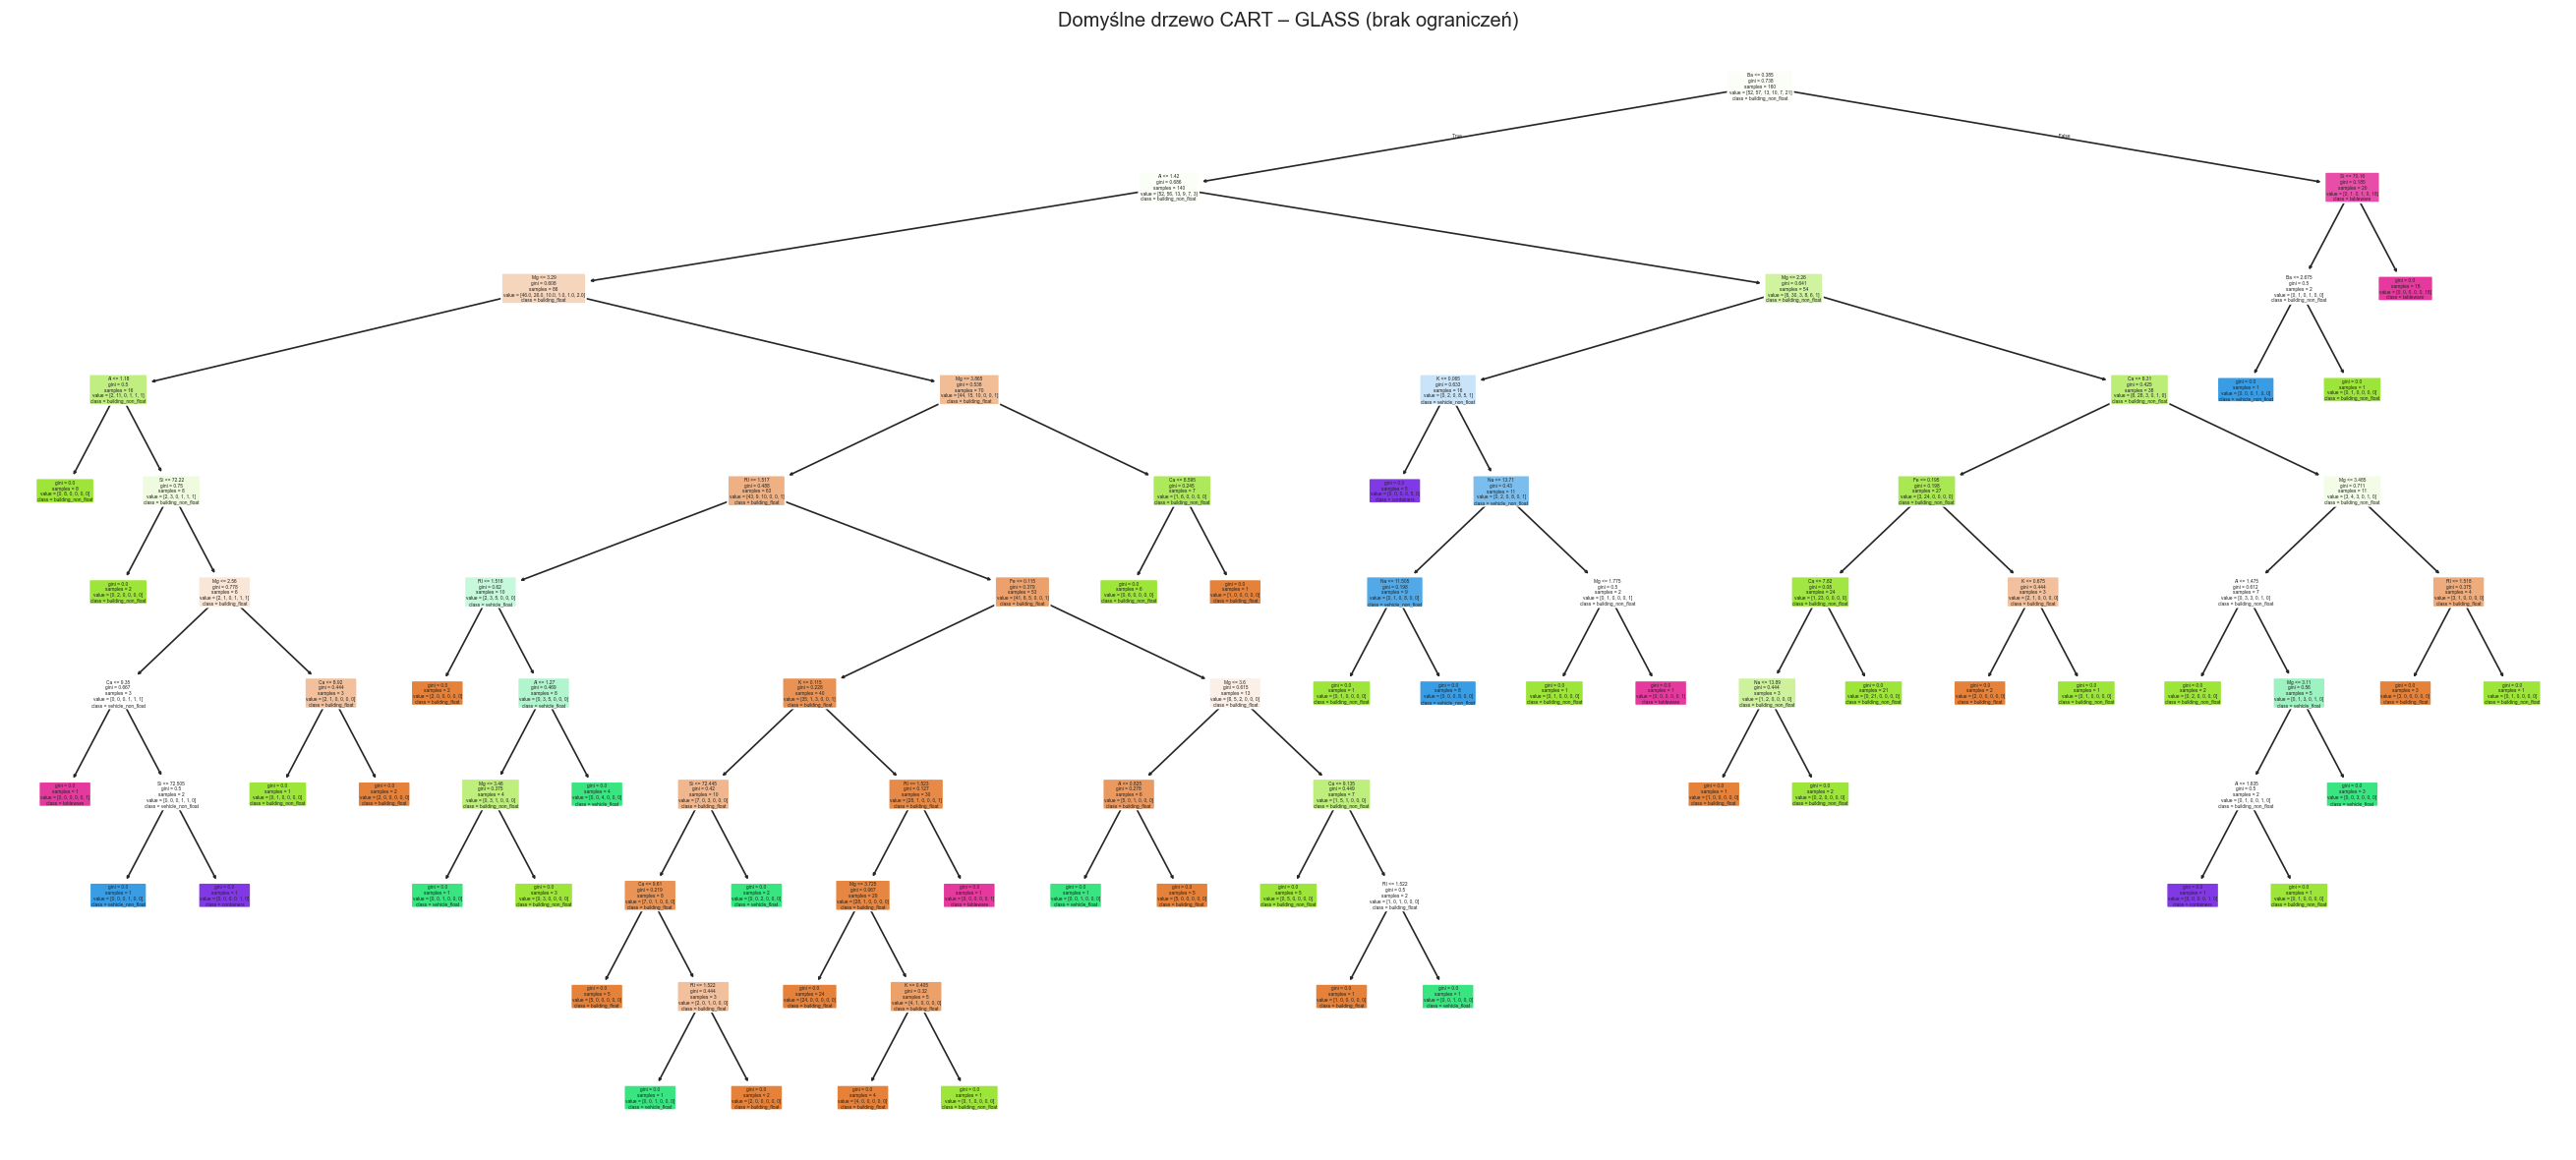

In [8]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_default, ax=ax,
          feature_names=X_glass.columns.tolist(),
          class_names=target_names_glass,
          filled=True, rounded=True,
          impurity=True)
ax.set_title('Domyślne drzewo CART – GLASS (brak ograniczeń)')
plt.tight_layout()
plt.show()

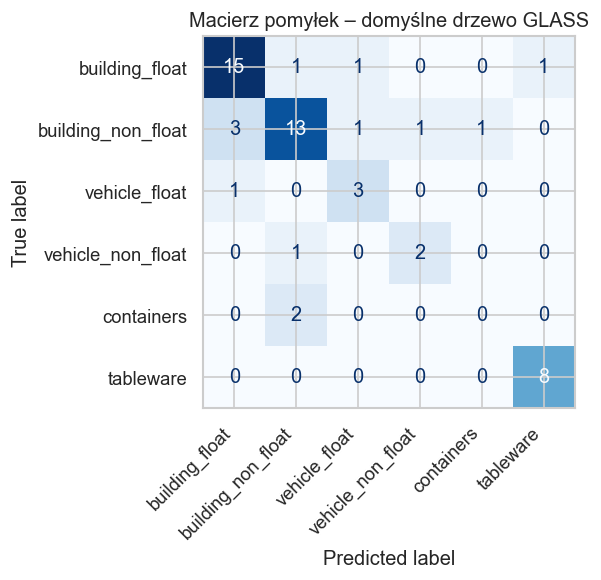

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_te_g, y_pred_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=target_names_glass)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek – domyślne drzewo GLASS')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.1 Wpływ `max_depth`

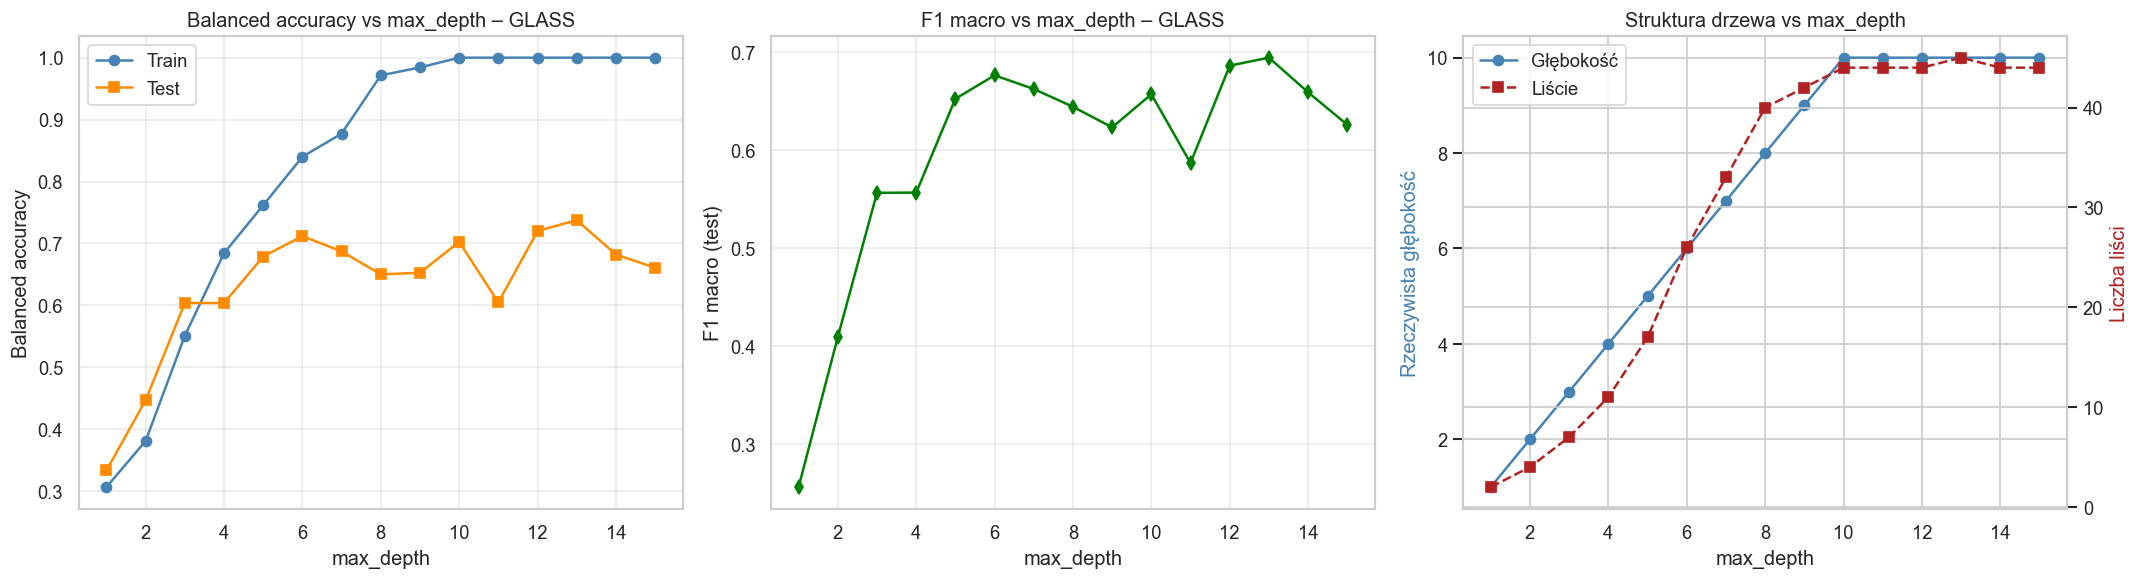

In [30]:
depths = range(1, 16)
train_bacc, test_bacc, n_leaves, depth_vals, f1_test = [], [], [], [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_tr_g, y_tr_g)
    y_pred = clf.predict(X_te_g)
    train_bacc.append(balanced_accuracy_score(y_tr_g, clf.predict(X_tr_g)))
    test_bacc.append(balanced_accuracy_score(y_te_g, y_pred))
    f1_test.append(f1_score(y_te_g, y_pred, average='macro'))
    n_leaves.append(clf.get_n_leaves())
    depth_vals.append(clf.get_depth())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Balanced accuracy
axes[0].plot(depths, train_bacc, 'o-', label='Train', color='steelblue')
axes[0].plot(depths, test_bacc,  's-', label='Test',  color='darkorange')
axes[0].set_xlabel('max_depth'); axes[0].set_ylabel('Balanced accuracy')
axes[0].set_title('Balanced accuracy vs max_depth – GLASS')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# F1
axes[1].plot(depths, f1_test, 'd-', color='green')
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('F1 macro (test)')
axes[1].set_title('F1 macro vs max_depth – GLASS')
axes[1].grid(True, alpha=0.4)

# Struktura
ax3 = axes[2]
ax3b = ax3.twinx()
ax3.plot(depths, depth_vals,  'o-', color='steelblue', label='Głębokość')
ax3b.plot(depths, n_leaves, 's--', color='firebrick', label='Liście')
ax3.set_xlabel('max_depth'); ax3.set_ylabel('Rzeczywista głębokość', color='steelblue')
ax3b.set_ylabel('Liczba liści', color='firebrick')
ax3.set_title('Struktura drzewa vs max_depth')
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, loc='upper left')

plt.tight_layout(); plt.show()


### 3.2 Wpływ `min_samples_leaf`

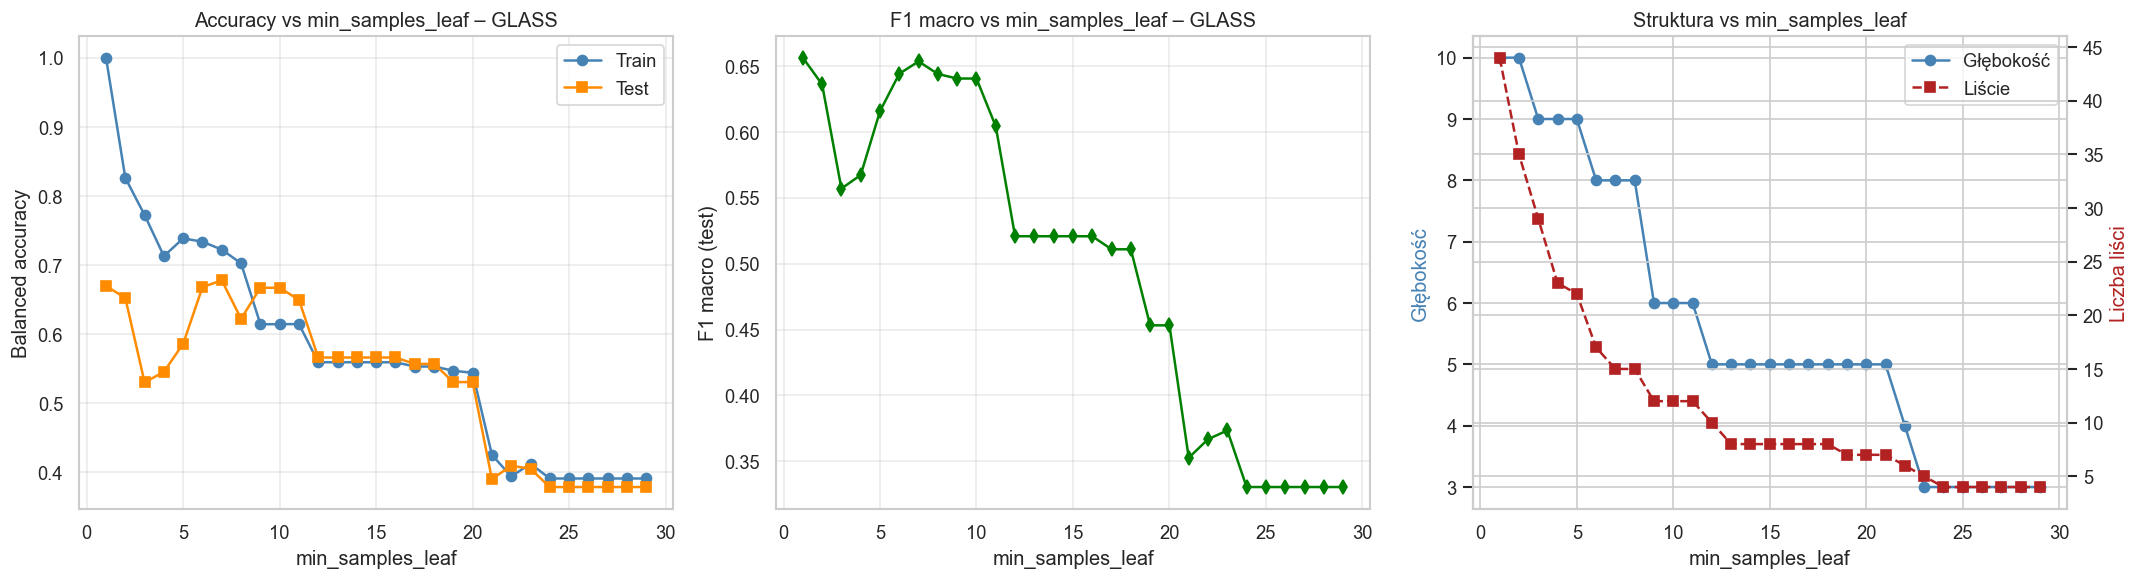

Najlepszy min_samples_leaf: 7 (acc=0.6779)


In [31]:
leaf_sizes = range(1, 30)
train_bmsl, test_bmsl, depth_msl, leaves_msl, f1_msl = [], [], [], [], []

for msl in leaf_sizes:
    clf = DecisionTreeClassifier(min_samples_leaf=msl)
    clf.fit(X_tr_g, y_tr_g)
    y_pred = clf.predict(X_te_g)
    train_bmsl.append(balanced_accuracy_score(y_tr_g, clf.predict(X_tr_g)))
    test_bmsl.append(balanced_accuracy_score(y_te_g, y_pred))
    f1_msl.append(f1_score(y_te_g, y_pred, average='macro'))
    depth_msl.append(clf.get_depth())
    leaves_msl.append(clf.get_n_leaves())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(leaf_sizes, train_bmsl, 'o-', label='Train', color='steelblue')
axes[0].plot(leaf_sizes, test_bmsl,  's-', label='Test',  color='darkorange')
axes[0].set_xlabel('min_samples_leaf'); axes[0].set_ylabel('Balanced accuracy')
axes[0].set_title('Accuracy vs min_samples_leaf – GLASS')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(leaf_sizes, f1_msl, 'd-', color='green')
axes[1].set_xlabel('min_samples_leaf'); axes[1].set_ylabel('F1 macro (test)')
axes[1].set_title('F1 macro vs min_samples_leaf – GLASS')
axes[1].grid(True, alpha=0.4)

ax3 = axes[2]; ax3b = ax3.twinx()
ax3.plot(leaf_sizes, depth_msl,  'o-', color='steelblue', label='Głębokość')
ax3b.plot(leaf_sizes, leaves_msl,'s--', color='firebrick', label='Liście')
ax3.set_xlabel('min_samples_leaf'); ax3.set_ylabel('Głębokość', color='steelblue')
ax3b.set_ylabel('Liczba liści', color='firebrick')
ax3.set_title('Struktura vs min_samples_leaf')
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, loc='upper right')

plt.tight_layout(); plt.show()
print(f'Najlepszy min_samples_leaf: {list(leaf_sizes)[np.argmax(test_bmsl)]} (acc={max(test_bmsl):.4f})')


### 3.3 Pruning – wpływ `ccp_alpha`

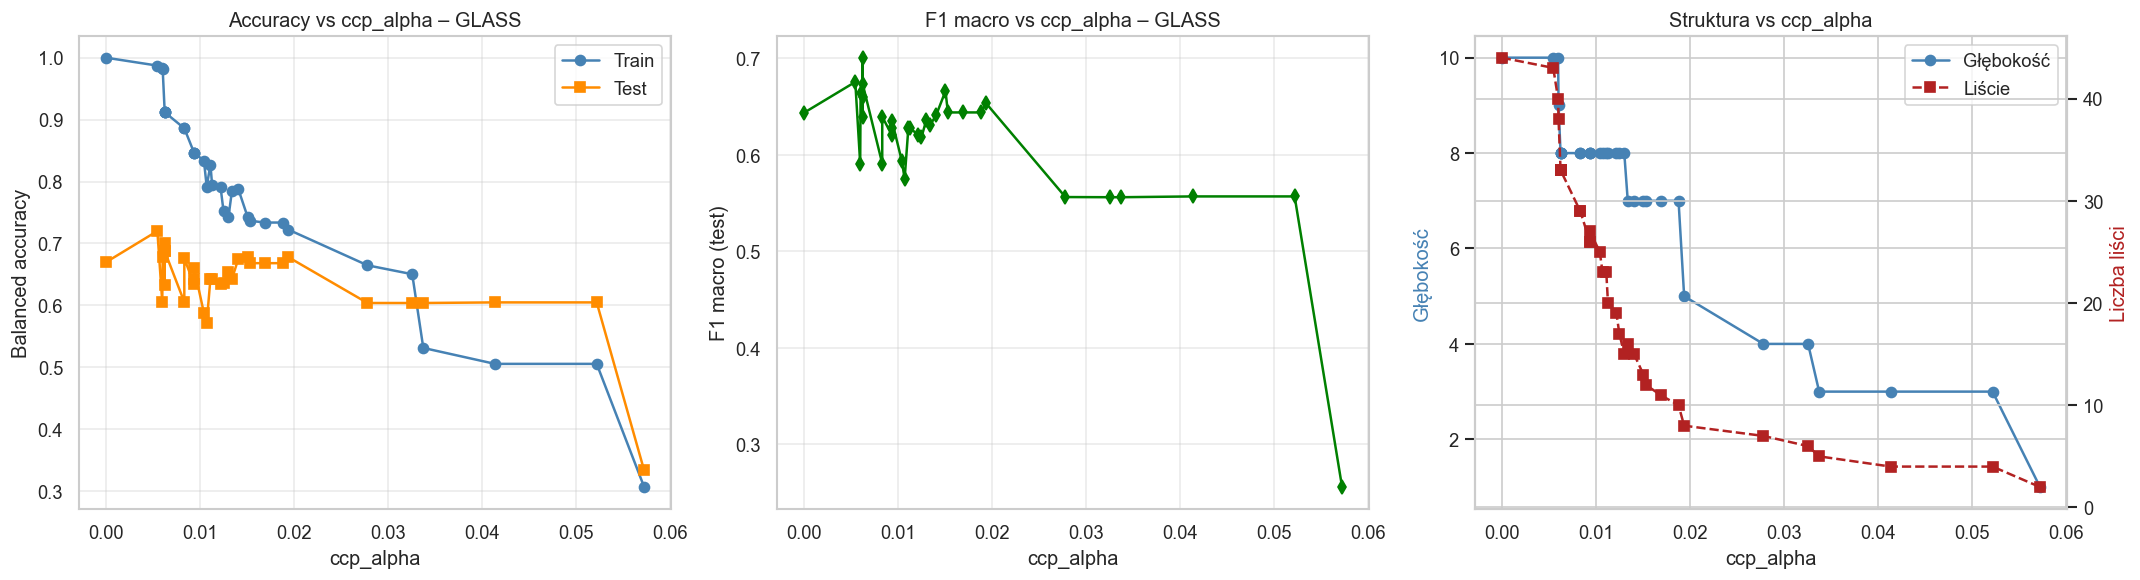

Najlepsza ccp_alpha: 0.00547


In [32]:
clf_full = DecisionTreeClassifier()
path = clf_full.cost_complexity_pruning_path(X_tr_g, y_tr_g)
ccp_alphas  = path.ccp_alphas
impurities  = path.impurities
alphas_test = ccp_alphas[:-1]

train_bccp, test_bccp, depth_ccp, leaves_ccp, f1_ccp = [], [], [], [], []

for alpha in alphas_test:
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_tr_g, y_tr_g)
    y_pred = clf.predict(X_te_g)
    train_bccp.append(balanced_accuracy_score(y_tr_g, clf.predict(X_tr_g)))
    test_bccp.append(balanced_accuracy_score(y_te_g, y_pred))
    f1_ccp.append(f1_score(y_te_g, y_pred, average='macro'))
    depth_ccp.append(clf.get_depth())
    leaves_ccp.append(clf.get_n_leaves())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(alphas_test, train_bccp, 'o-', label='Train', color='steelblue')
axes[0].plot(alphas_test, test_bccp,  's-', label='Test',  color='darkorange')
axes[0].set_xlabel('ccp_alpha'); axes[0].set_ylabel('Balanced accuracy')
axes[0].set_title('Accuracy vs ccp_alpha – GLASS')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(alphas_test, f1_ccp, 'd-', color='green')
axes[1].set_xlabel('ccp_alpha'); axes[1].set_ylabel('F1 macro (test)')
axes[1].set_title('F1 macro vs ccp_alpha – GLASS')
axes[1].grid(True, alpha=0.4)

ax3 = axes[2]; ax3b = ax3.twinx()
ax3.plot(alphas_test, depth_ccp,  'o-', color='steelblue', label='Głębokość')
ax3b.plot(alphas_test, leaves_ccp,'s--', color='firebrick', label='Liście')
ax3.set_xlabel('ccp_alpha'); ax3.set_ylabel('Głębokość', color='steelblue')
ax3b.set_ylabel('Liczba liści', color='firebrick')
ax3.set_title('Struktura vs ccp_alpha')
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, loc='upper right')

plt.tight_layout(); plt.show()
print(f'Najlepsza ccp_alpha: {alphas_test[np.argmax(test_bccp)]:.5f}')


### 3.4 Wizualizacja wybranych drzew po strojeniu

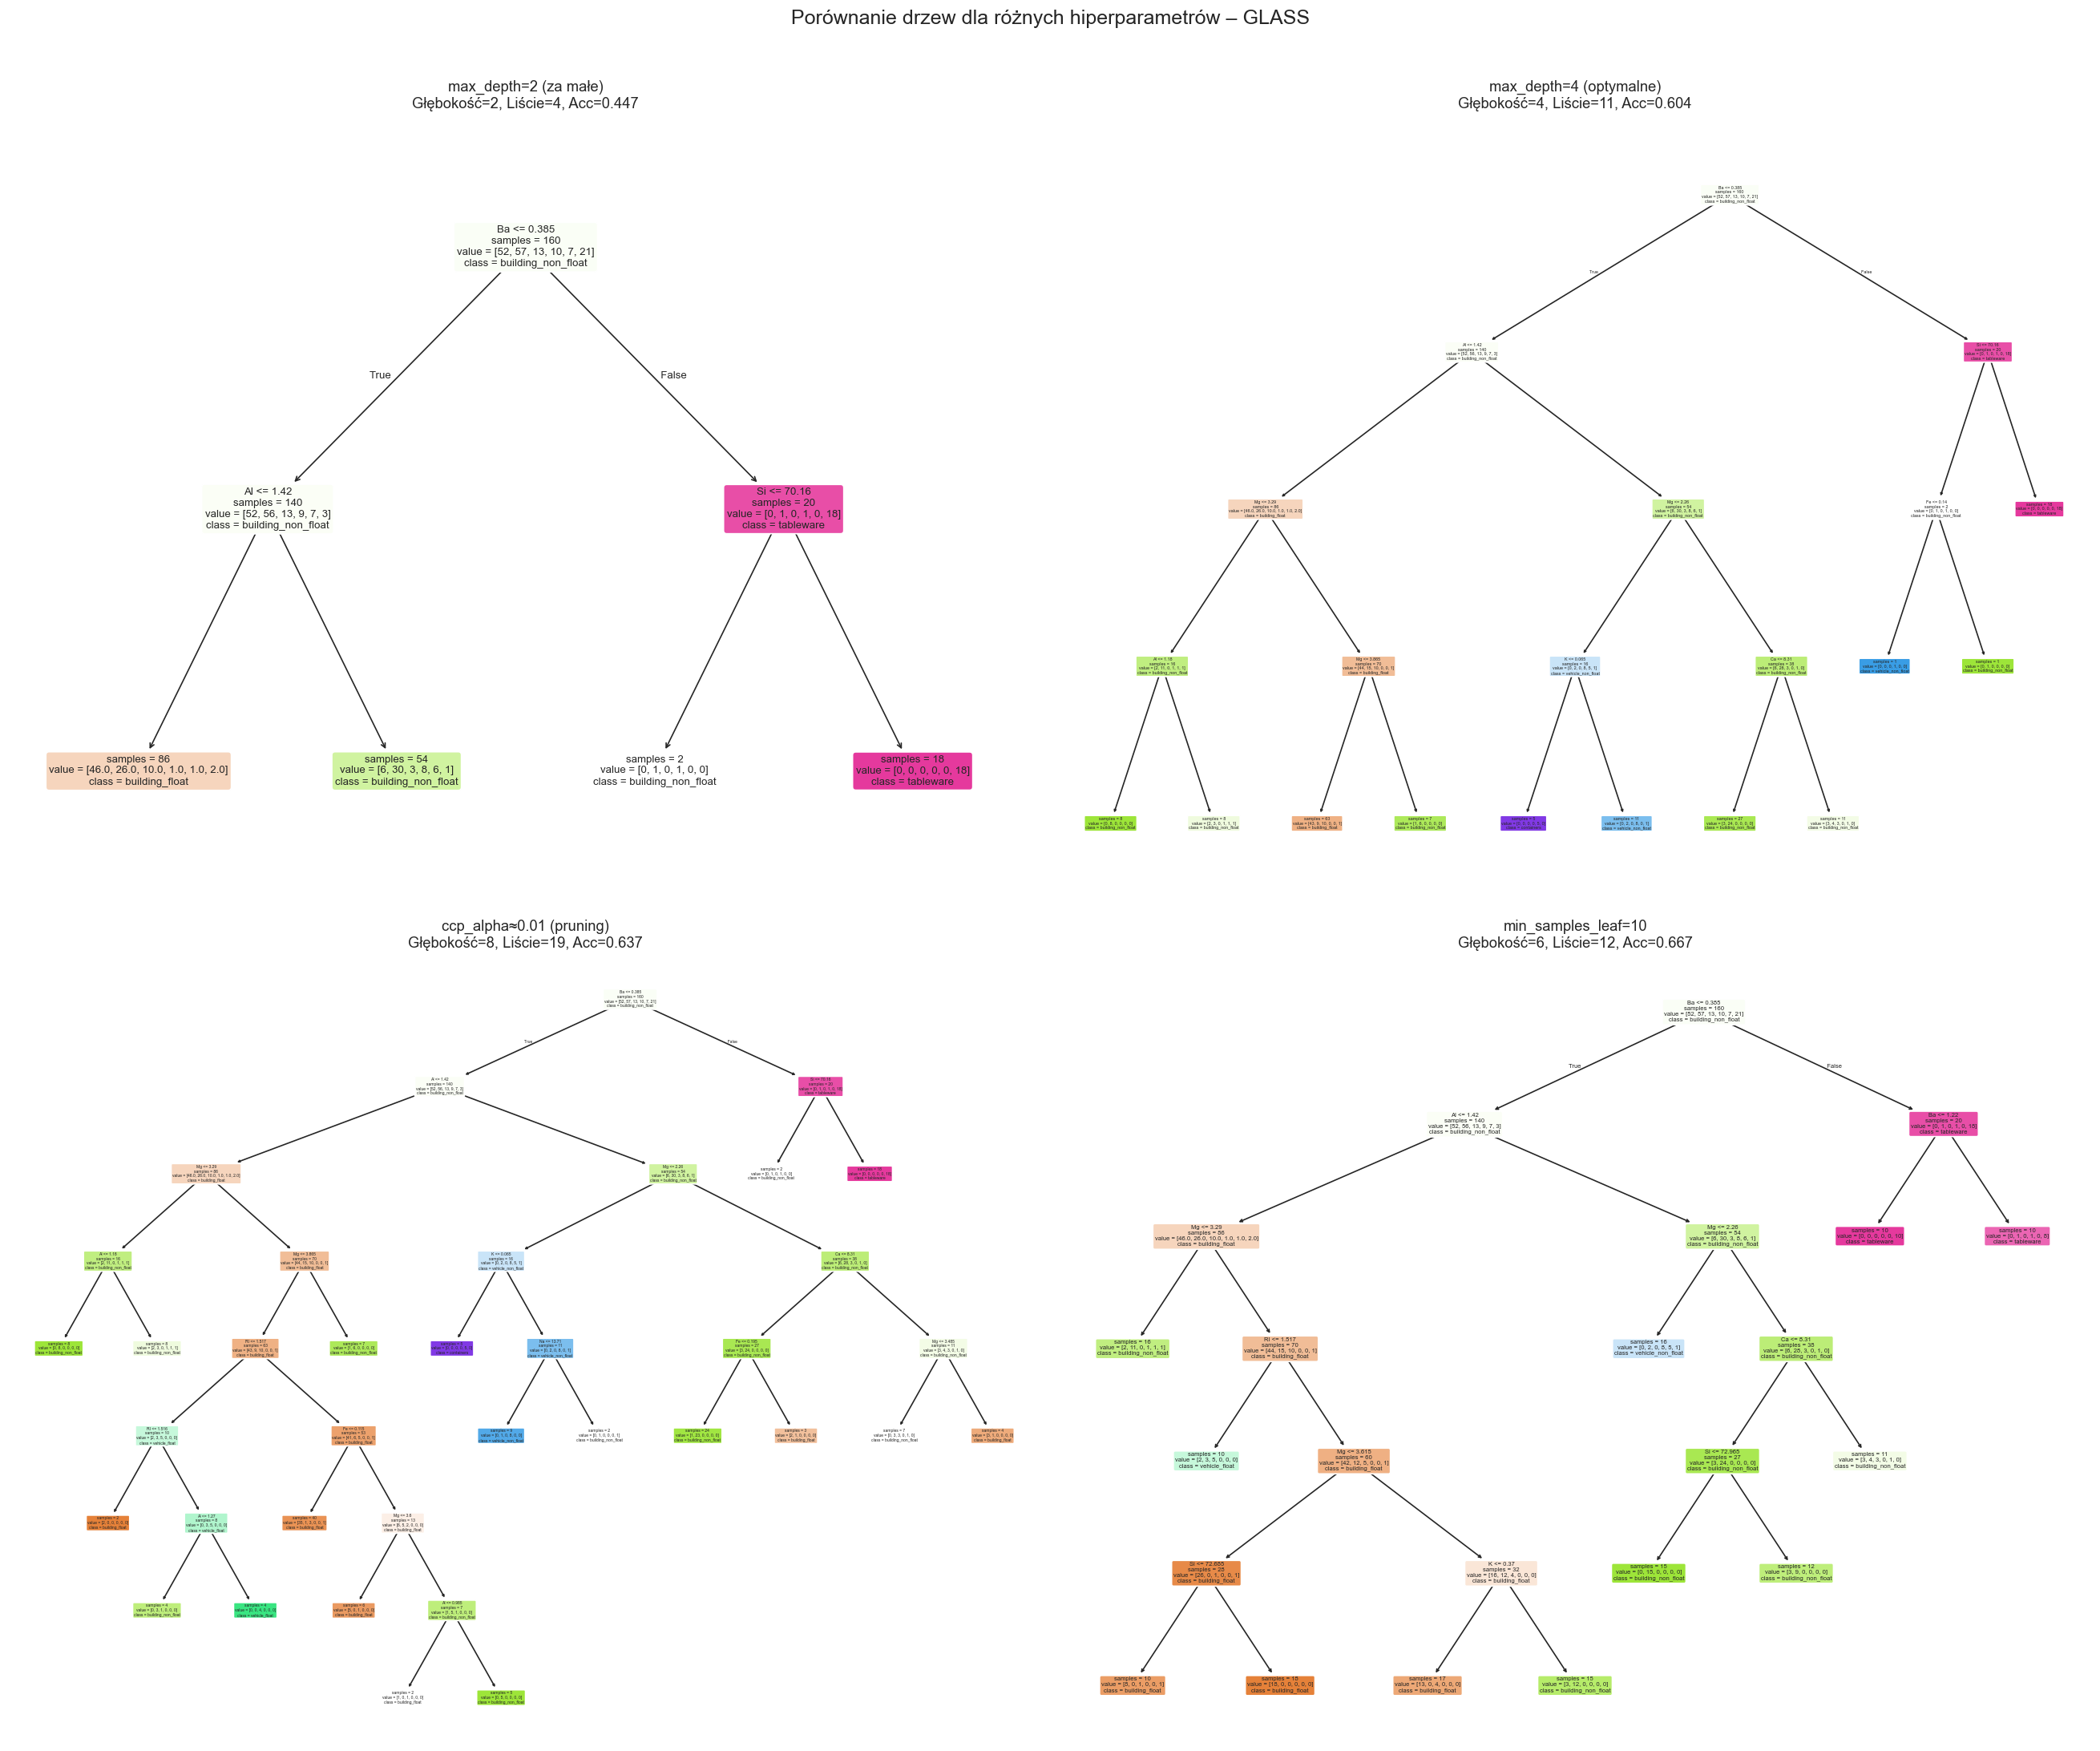

In [14]:
configs = {
    'max_depth=2 (za małe)':      dict(max_depth=2),
    'max_depth=4 (optymalne)':    dict(max_depth=4),
    'ccp_alpha≈0.01 (pruning)':   dict(ccp_alpha=0.012),
    'min_samples_leaf=10':        dict(min_samples_leaf=10),
}

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, (title, params) in zip(axes, configs.items()):
    clf = DecisionTreeClassifier(**params)
    clf.fit(X_tr_g, y_tr_g)
    acc = balanced_accuracy_score(y_te_g, clf.predict(X_te_g))
    plot_tree(clf, ax=ax, feature_names=X_glass.columns.tolist(),
              class_names=target_names_glass,
              filled=True, rounded=True, impurity=False)
    ax.set_title(
        f'{title}\nGłębokość={clf.get_depth()}, '
        f'Liście={clf.get_n_leaves()}, Acc={acc:.3f}',
        fontsize=11
    )

plt.suptitle('Porównanie drzew dla różnych hiperparametrów – GLASS', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Ważność cech

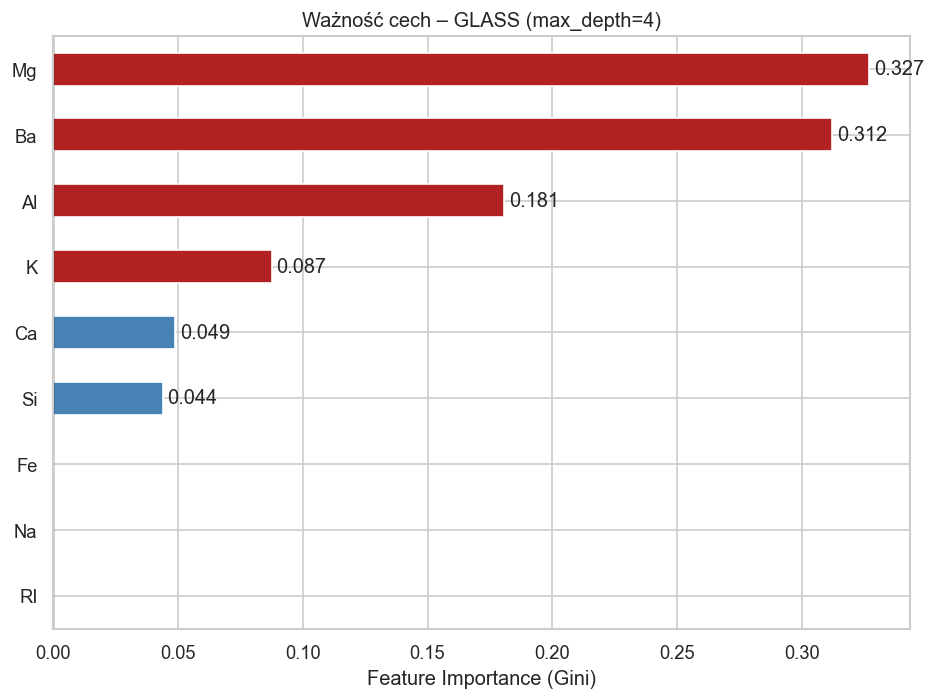

In [33]:
clf_opt = DecisionTreeClassifier(max_depth=4)
clf_opt.fit(X_tr_g, y_tr_g)

importances = pd.Series(clf_opt.feature_importances_, index=X_glass.columns.tolist())
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_fi = ['firebrick' if v > importances.median() else 'steelblue'
             for v in importances.values]
importances.plot.barh(ax=ax, color=colors_fi)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ważność cech – GLASS (max_depth=4)')
ax.set_xlabel('Feature Importance (Gini)')
for i, v in enumerate(importances.values):
    if v > 0.01:
        ax.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

### 3.6 Heatmapa – siatka hiperparametrów (max_depth × min_samples_leaf)

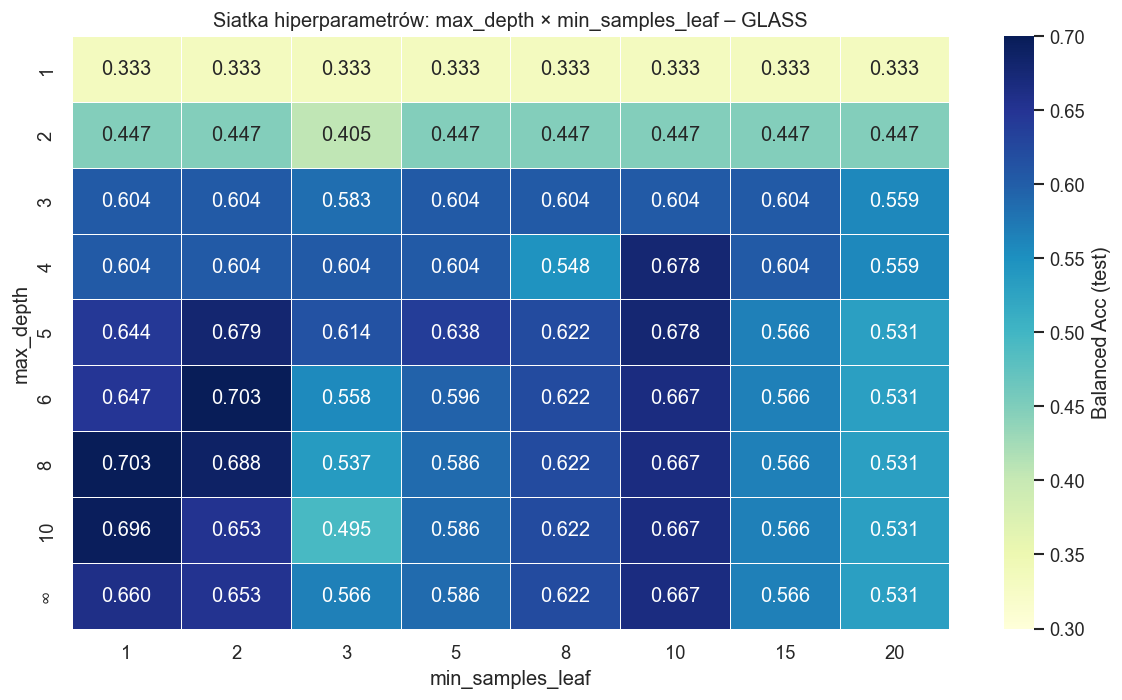

In [35]:
depths_grid = [1, 2, 3, 4, 5, 6, 8, 10, None]
msl_grid = [1, 2, 3, 5, 8, 10, 15, 20]

heat_matrix = np.zeros((len(depths_grid), len(msl_grid)))

for i, d in enumerate(depths_grid):
    for j, msl in enumerate(msl_grid):
        clf = DecisionTreeClassifier(max_depth=d, min_samples_leaf=msl)
        clf.fit(X_tr_g, y_tr_g)
        heat_matrix[i, j] = balanced_accuracy_score(y_te_g, clf.predict(X_te_g))

heat_df = pd.DataFrame(
    heat_matrix,
    index=[str(d) if d else '∞' for d in depths_grid],
    columns=msl_grid
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_df, ax=ax, annot=True, fmt='.3f',
            cmap='YlGnBu', vmin=0.3, vmax=0.7,
            linewidths=0.5,
            cbar_kws={'label': 'Balanced Acc (test)'})
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')
ax.set_title('Siatka hiperparametrów: max_depth × min_samples_leaf – GLASS')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

param_grid_g = {
    'max_depth':        [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [1, 2, 3, 5, 8, 10, 15],
    'ccp_alpha':        [0.0, 0.001, 0.005, 0.01, 0.02],
}
scorer_bal = make_scorer(balanced_accuracy_score)

gs_glass = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid_g,
    cv=StratifiedKFold(n_splits=5, shuffle=True),
    scoring=scorer_bal,
    n_jobs=-1, refit=True, return_train_score=True
)
gs_glass.fit(X_glass, y_glass)

print('=== GLASS – najlepsze parametry ===')
print(gs_glass.best_params_)
print(f'Balanced accuracy (CV):   {gs_glass.best_score_:.4f}')
y_pred_gs_g = gs_glass.best_estimator_.predict(X_te_g)
print(f'Balanced accuracy (test): {balanced_accuracy_score(y_te_g, y_pred_gs_g):.4f}')
print(f'F1 macro (test):          {f1_score(y_te_g, y_pred_gs_g, average="macro"):.4f}')


=== GLASS – najlepsze parametry ===
{'ccp_alpha': 0.001, 'max_depth': 8, 'min_samples_leaf': 2}
Balanced accuracy (CV):   0.6586
Balanced accuracy (test): 0.7445
F1 macro (test):          0.7561


---
## 4. Walidacja krzyżowa – zwykła vs. stratyfikowana

In [20]:
k_folds = 5
clf_cv = DecisionTreeClassifier(max_depth=4)
kf   = KFold(n_splits=k_folds, shuffle=True)
skf  = StratifiedKFold(n_splits=k_folds, shuffle=True)

scores_kf  = cross_val_score(clf_cv, X_glass, y_glass, cv=kf,  scoring='accuracy')
scores_skf = cross_val_score(clf_cv, X_glass, y_glass, cv=skf, scoring='accuracy')

print(f'KFold:            mean={scores_kf.mean():.4f}  std={scores_kf.std():.4f}')
print(f'Stratified KFold: mean={scores_skf.mean():.4f}  std={scores_skf.std():.4f}')

KFold:            mean=0.6402  std=0.0429
Stratified KFold: mean=0.6777  std=0.0587


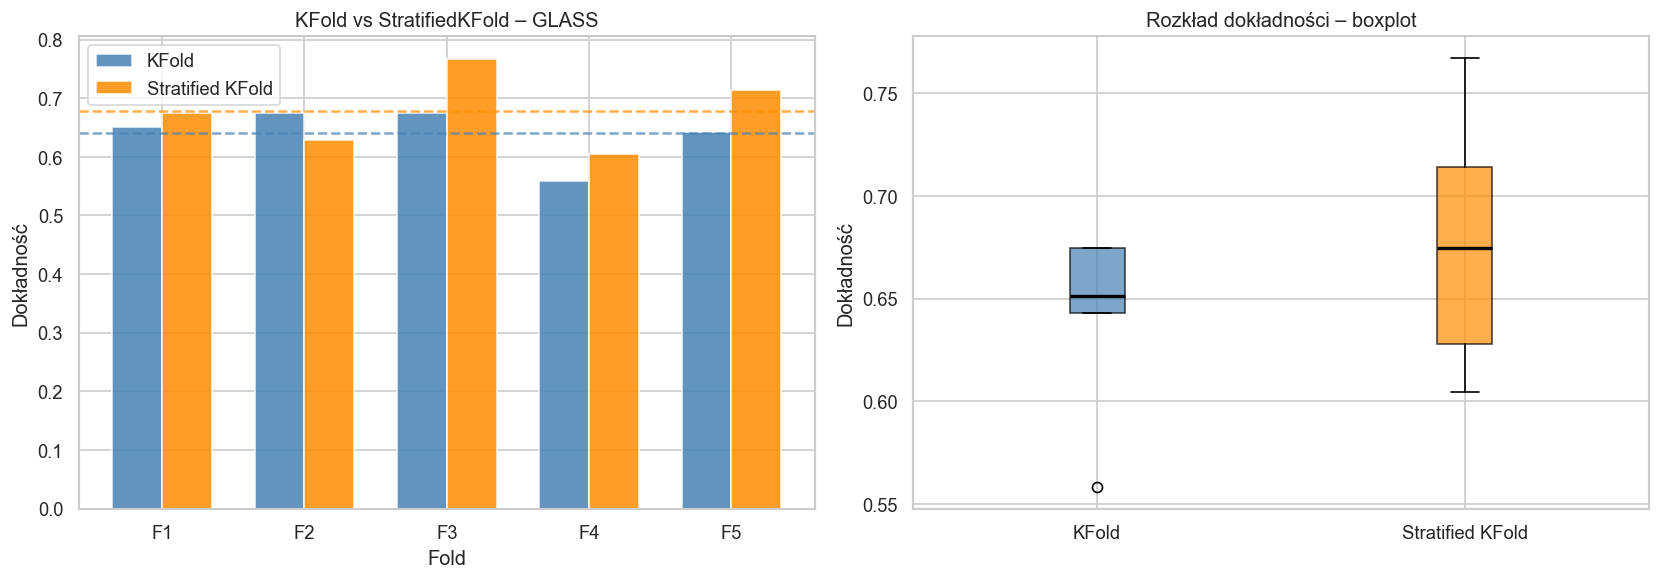

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(k_folds)
w = 0.35
axes[0].bar(x_pos - w/2, scores_kf,  w, label='KFold',            color='steelblue', alpha=0.85)
axes[0].bar(x_pos + w/2, scores_skf, w, label='Stratified KFold', color='darkorange', alpha=0.85)
axes[0].axhline(scores_kf.mean(),  color='steelblue', linestyle='--', alpha=0.7)
axes[0].axhline(scores_skf.mean(), color='darkorange', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Dokładność')
axes[0].set_title('KFold vs StratifiedKFold – GLASS')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels([f'F{i+1}' for i in x_pos])
axes[0].legend()

data_bp = [scores_kf, scores_skf]
bp = axes[1].boxplot(data_bp, patch_artist=True,
                     labels=['KFold', 'Stratified KFold'],
                     medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], ['steelblue','darkorange']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_ylabel('Dokładność')
axes[1].set_title('Rozkład dokładności – boxplot')

plt.tight_layout()
plt.show()

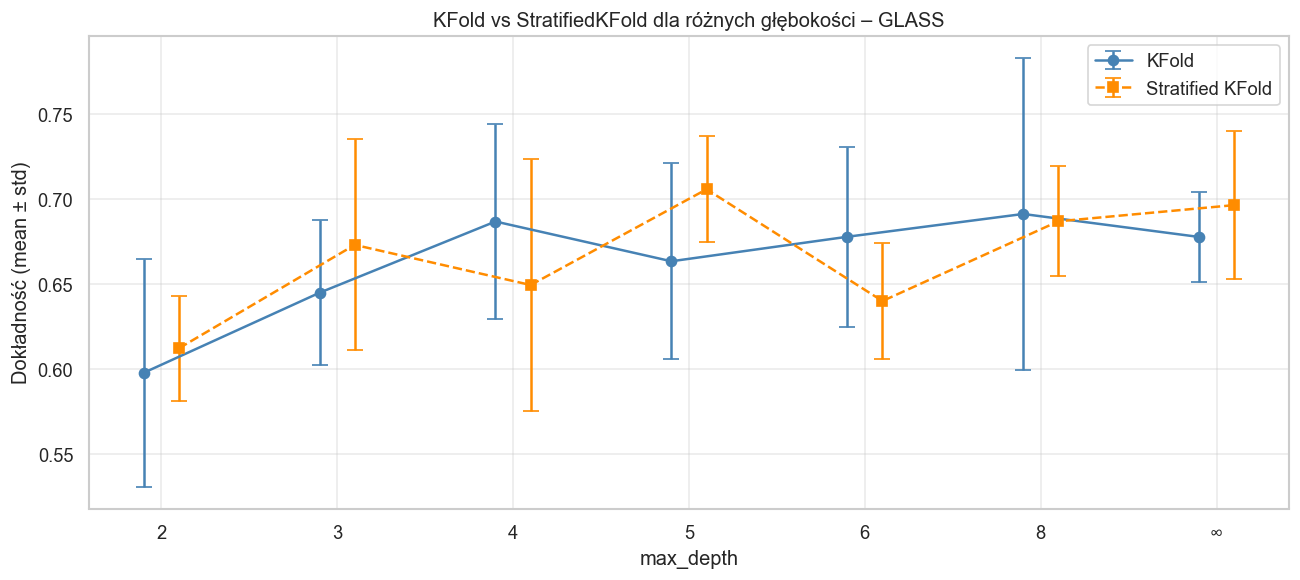

depth  KFold_mean  KFold_std  SKF_mean  SKF_std
    2      0.5978     0.0671    0.6122   0.0310
    3      0.6449     0.0426    0.6730   0.0619
    4      0.6867     0.0574    0.6494   0.0742
    5      0.6633     0.0575    0.7056   0.0311
    6      0.6777     0.0529    0.6400   0.0339
    8      0.6911     0.0919    0.6868   0.0324
    ∞      0.6776     0.0263    0.6963   0.0435


In [44]:
depths_cv = [2, 3, 4, 5, 6, 8, None]
results_cv = []

for d in depths_cv:
    clf_d = DecisionTreeClassifier(max_depth=d)
    kf_s   = cross_val_score(clf_d, X_glass, y_glass, cv=kf,  scoring='accuracy')
    skf_s  = cross_val_score(clf_d, X_glass, y_glass, cv=skf, scoring='accuracy')
    results_cv.append({'depth': str(d) if d else '∞',
                       'KFold_mean': kf_s.mean(), 'KFold_std': kf_s.std(),
                       'SKF_mean': skf_s.mean(), 'SKF_std': skf_s.std()})

cv_df = pd.DataFrame(results_cv)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(depths_cv))
ax.errorbar(x-0.1, cv_df['KFold_mean'], yerr=cv_df['KFold_std'],
            fmt='o-', capsize=5, label='KFold', color='steelblue')
ax.errorbar(x+0.1, cv_df['SKF_mean'], yerr=cv_df['SKF_std'],
            fmt='s--', capsize=5, label='Stratified KFold', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(cv_df['depth'])
ax.set_xlabel('max_depth')
ax.set_ylabel('Dokładność (mean ± std)')
ax.set_title('KFold vs StratifiedKFold dla różnych głębokości – GLASS')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(cv_df.round(4).to_string(index=False))

---
## 6. Wpływ wag klas – PCB

In [45]:
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_pcb_imp, y_pcb_s, test_size=0.25,
    stratify=y_pcb_s
)

print(f'Train: {y_tr_p.value_counts().to_dict()}')
print(f'Test:  {y_te_p.value_counts().to_dict()}')

Train: {0: 30985, 1: 1568}
Test:  {0: 10329, 1: 523}


In [46]:
weight_configs = {
    'Bez wag (None)':      None,
    'Balanced':            'balanced',
    'Manual 1:5':         {0: 1, 1: 5},
    'Manual 1:10':        {0: 1, 1: 10},
    'Manual 1:20':        {0: 1, 1: 20},
}

results_pcb = []
for label, cw in weight_configs.items():
    clf_pcb = DecisionTreeClassifier(
        max_depth=5, class_weight=cw
    )
    clf_pcb.fit(X_tr_p, y_tr_p)
    y_pred_p = clf_pcb.predict(X_te_p)
    results_pcb.append({
        'Konfiguracja': label,
        'Balanced accuracy':     balanced_accuracy_score(y_te_p, y_pred_p),
        'F1 (bankrupt)': f1_score(y_te_p, y_pred_p, pos_label=1),
        'F1 (macro)':   f1_score(y_te_p, y_pred_p, average='macro'),
        'Recall (1)':   classification_report(y_te_p, y_pred_p, output_dict=True)['1']['recall'],
        'Precision (1)': classification_report(y_te_p, y_pred_p, output_dict=True)['1']['precision'],
    })

res_df = pd.DataFrame(results_pcb)
print(res_df.round(4).to_string(index=False))

  Konfiguracja  Balanced accuracy  F1 (bankrupt)  F1 (macro)  Recall (1)  Precision (1)
Bez wag (None)             0.5859         0.2862      0.6323      0.1740         0.8053
      Balanced             0.7728         0.2461      0.5556      0.7744         0.1463
    Manual 1:5             0.6465         0.4159      0.6974      0.3002         0.6767
   Manual 1:10             0.7392         0.3058      0.6170      0.5946         0.2058
   Manual 1:20             0.7730         0.2464      0.5560      0.7744         0.1465


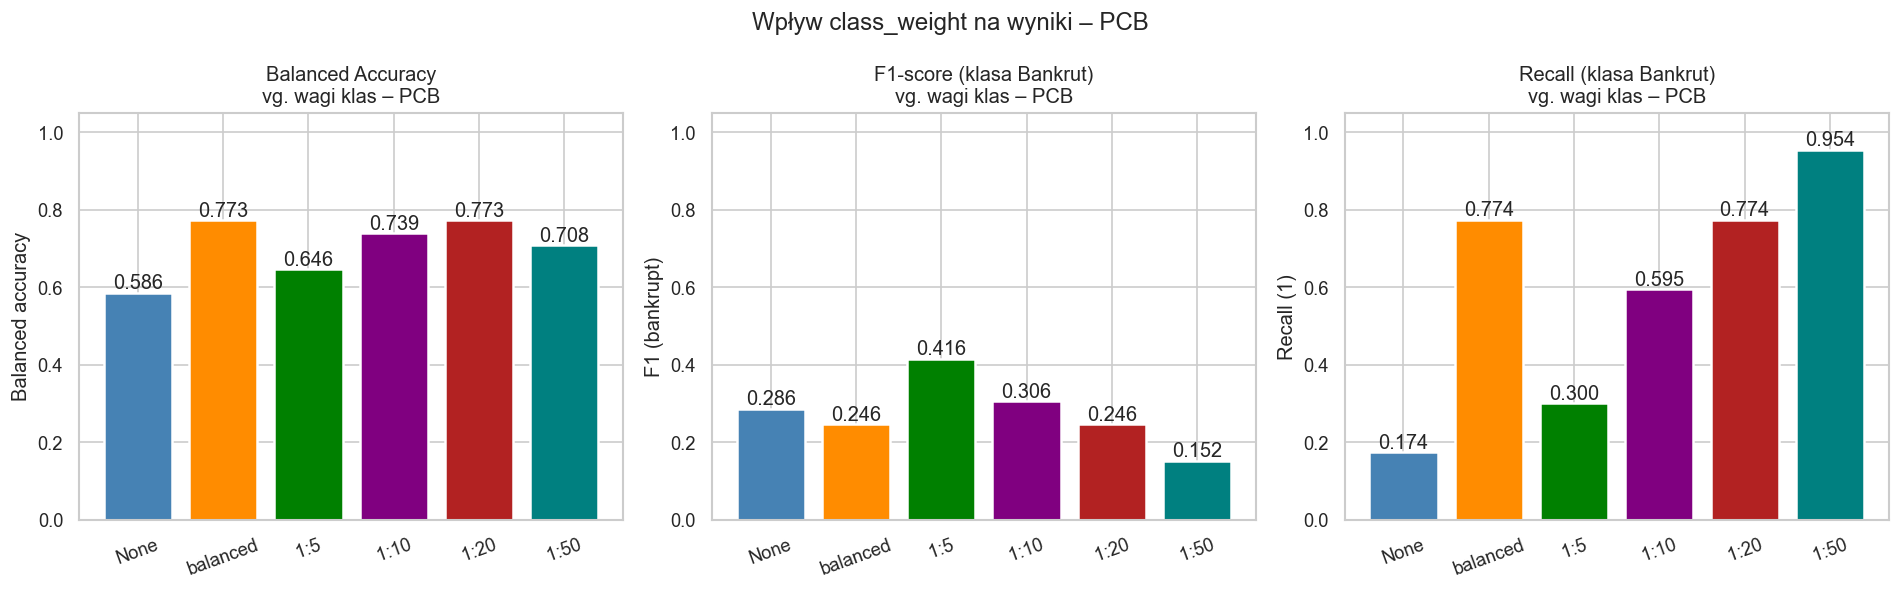

In [47]:
labels_short = ['None', 'balanced', '1:5', '1:10', '1:20', '1:50']

# compute metrics for Manual 1:50 and rebuild res_df to avoid duplicate rows on re-run
clf_1_50 = DecisionTreeClassifier(max_depth=5, class_weight={0:1, 1:50})
clf_1_50.fit(X_tr_p, y_tr_p)
y_pred_150 = clf_1_50.predict(X_te_p)
cr = classification_report(y_te_p, y_pred_150, output_dict=True)

res_df = res_df[res_df['Konfiguracja'] != 'Manual 1:50'].copy()
res_df.loc[len(res_df)] = [
    'Manual 1:50',
    balanced_accuracy_score(y_te_p, y_pred_150),
    f1_score(y_te_p, y_pred_150, pos_label=1),
    f1_score(y_te_p, y_pred_150, average='macro'),
    cr['1']['recall'],
    cr['1']['precision'],
]
res_df = res_df.reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(labels_short))
bar_colors = ['steelblue', 'darkorange', 'green', 'purple', 'firebrick', 'teal']

for ax, col, title in zip(axes,
    ['Balanced accuracy', 'F1 (bankrupt)', 'Recall (1)'],
    ['Balanced Accuracy', 'F1-score (klasa Bankrut)', 'Recall (klasa Bankrut)']):
    bars = ax.bar(x, res_df[col], color=bar_colors, linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=20)
    ax.set_title(f'{title}\nvg. wagi klas – PCB')
    ax.set_ylabel(col)
    ax.set_ylim(0, 1.05)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center')

plt.suptitle('Wpływ class_weight na wyniki – PCB')
plt.tight_layout()
plt.show()


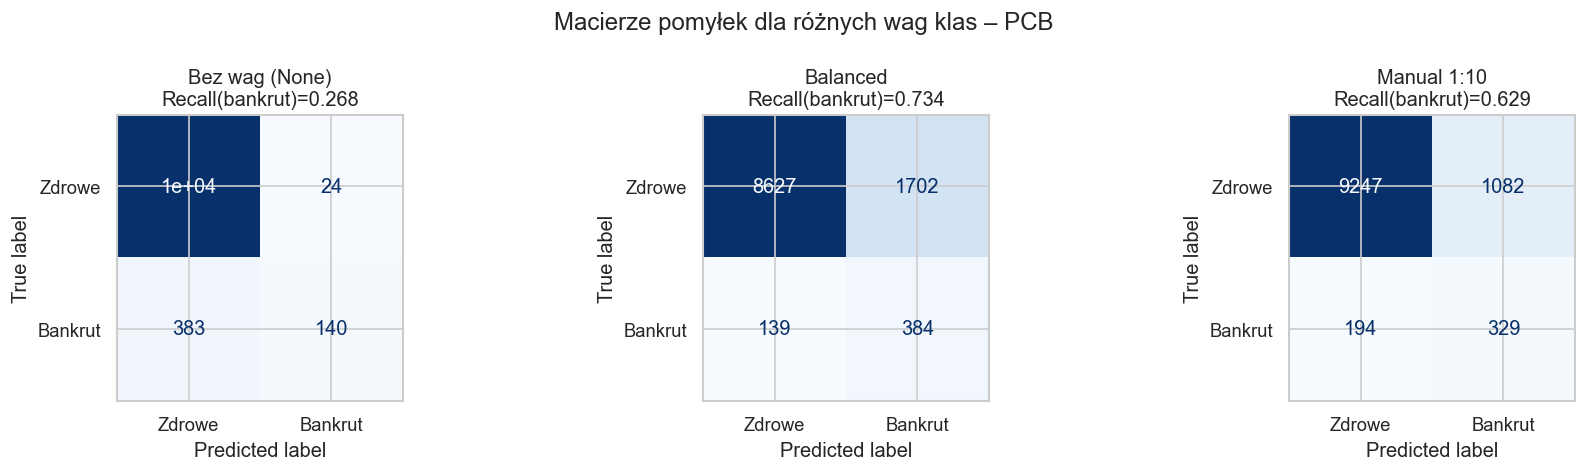

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
selected = [
    ('Bez wag (None)', None),
    ('Balanced',       'balanced'),
    ('Manual 1:10',   {0:1, 1:10}),
]

for ax, (label, cw) in zip(axes, selected):
    clf_p = DecisionTreeClassifier(max_depth=5, class_weight=cw)
    clf_p.fit(X_tr_p, y_tr_p)
    y_pred_p = clf_p.predict(X_te_p)
    cm_p = confusion_matrix(y_te_p, y_pred_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_p,
                                  display_labels=['Zdrowe', 'Bankrut'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    rec = cm_p[1,1] / (cm_p[1,0] + cm_p[1,1]) if (cm_p[1,0]+cm_p[1,1]) > 0 else 0
    ax.set_title(f'{label}\nRecall(bankrut)={rec:.3f}')

plt.suptitle('Macierze pomyłek dla różnych wag klas – PCB')
plt.tight_layout()
plt.show()

### 6.5 Strojenie – GridSearchCV (balanced accuracy) – PCB

Przy silnym niezbalansowaniu (~3.9% bankrutów) `balanced_accuracy` wymusza model który nie ignoruje klasy mniejszościowej. `class_weight='balanced'` wbudowane w klasyfikator.

In [ ]:
gs_pcb = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced'),
    param_grid_g,
    cv=StratifiedKFold(n_splits=5, shuffle=True),
    scoring=scorer_bal,
    n_jobs=-1, 
    refit=True, 
    return_train_score=True
)
gs_pcb.fit(X_pcb_imp, y_pcb_s)

print('=== PCB – najlepsze parametry ===')
print(gs_pcb.best_params_)
print(f'Balanced accuracy (CV):   {gs_pcb.best_score_:.4f}')
y_pred_gs_p = gs_pcb.best_estimator_.predict(X_te_p)
print(f'Balanced accuracy (test): {balanced_accuracy_score(y_te_p, y_pred_gs_p):.4f}')
print(f'F1 macro (test):          {f1_score(y_te_p, y_pred_gs_p, average="macro"):.4f}')
print(f'Recall bankrut (test):    {f1_score(y_te_p, y_pred_gs_p, pos_label=1, average="binary"):.4f}')


=== PCB – najlepsze parametry ===
{'ccp_alpha': 0.001, 'max_depth': None, 'min_samples_leaf': 15}
Balanced accuracy (CV):   0.8131
Balanced accuracy (test): 0.8476
F1 macro (test):          0.5829
Recall bankrut (test):    0.2919


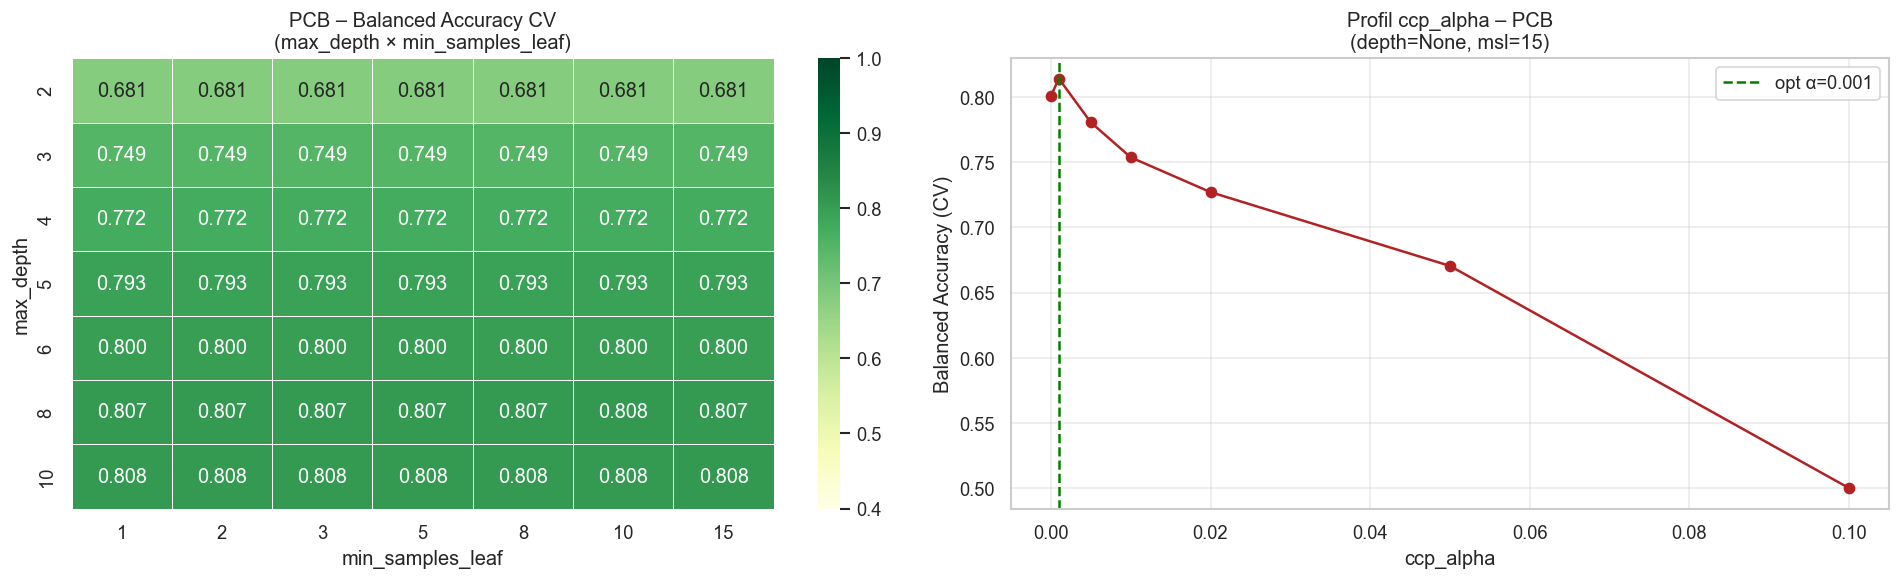

In [ ]:
res_gs_p = pd.DataFrame(gs_pcb.cv_results_)
pivot_p = (
    res_gs_p
    .groupby(['param_max_depth', 'param_min_samples_leaf'])['mean_test_score']
    .max().unstack()
)
pivot_p.index = [str(x) for x in pivot_p.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_p, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0],
            linewidths=0.3, vmin=0.6, vmax=0.77)
axes[0].set_title('PCB – Balanced Accuracy CV\n(max_depth × min_samples_leaf)')
axes[0].set_xlabel('min_samples_leaf'); axes[0].set_ylabel('max_depth')

best_dp   = gs_pcb.best_params_['max_depth']
best_mslp = gs_pcb.best_params_['min_samples_leaf']
alphas_profile = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
skf5 = StratifiedKFold(n_splits=5, shuffle=True)
cv_profile_p = []
for a in alphas_profile:
    clf_a = DecisionTreeClassifier(max_depth=best_dp, min_samples_leaf=best_mslp,
                                   ccp_alpha=a, class_weight='balanced')
    cv_profile_p.append(cross_val_score(clf_a, X_pcb_imp, y_pcb_s,
                                        cv=skf5, scoring=scorer_bal).mean())
axes[1].plot(alphas_profile, cv_profile_p, 'o-', color='firebrick')
axes[1].axvline(gs_pcb.best_params_['ccp_alpha'], color='green',
                linestyle='--', label=f'opt α={gs_pcb.best_params_["ccp_alpha"]:.3f}')
axes[1].set_xlabel('ccp_alpha'); axes[1].set_ylabel('Balanced Accuracy (CV)')
axes[1].set_title(f'Profil ccp_alpha – PCB\n(depth={best_dp}, msl={best_mslp})')
axes[1].legend(); axes[1].grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


---
## 7. Walidacja stratyfikowana vs. zwykła – PCB

In [ ]:
clf_pcb_cv = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
kf_p  = KFold(n_splits=10, shuffle=True)
skf_p = StratifiedKFold(n_splits=10, shuffle=True)

for metric in ['accuracy', 'f1', 'recall']:
    sc_kf  = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=kf_p,  scoring=metric)
    sc_skf = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=skf_p, scoring=metric)
    print(f'{metric:10s} | KFold: {sc_kf.mean():.4f} ± {sc_kf.std():.4f}  '
          f'| StratKFold: {sc_skf.mean():.4f} ± {sc_skf.std():.4f}')

accuracy   | KFold: 0.8005 ± 0.0179  | StratKFold: 0.7927 ± 0.0212
f1         | KFold: 0.2611 ± 0.0273  | StratKFold: 0.2723 ± 0.0167
recall     | KFold: 0.7527 ± 0.0266  | StratKFold: 0.7877 ± 0.0171


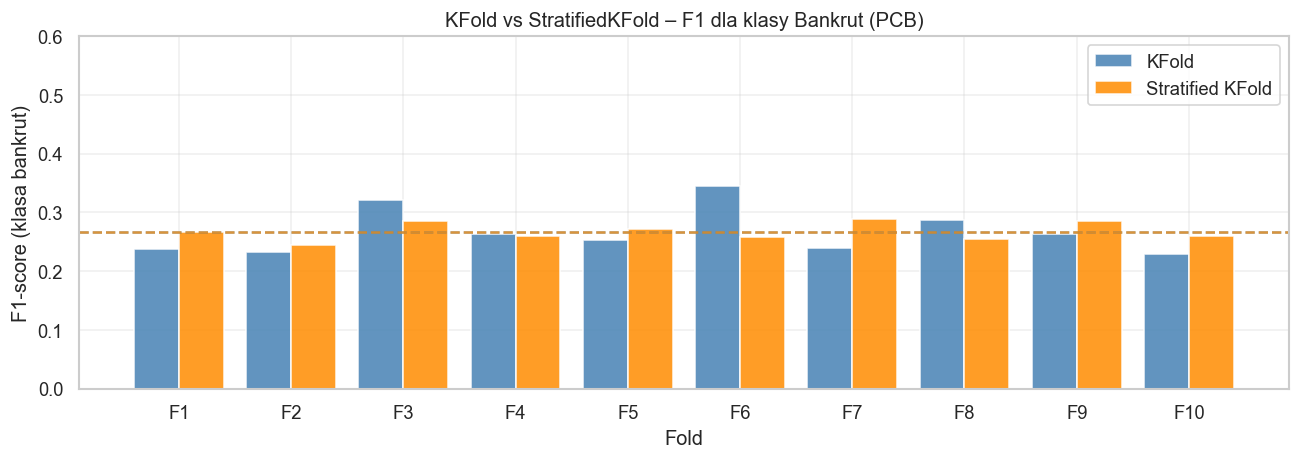

KFold std=0.0371   Stratified std=0.0140
> Przy niezbalansowanych danych KFold może przypadkowo wkładać wszystkie
  bankroty do jednego folda → wysoka wariancja. Stratyfikacja to stabilizuje.


In [ ]:
# Wizualizacja wariancji foldów dla PCB
sc_kf_f1  = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=kf_p,  scoring='f1')
sc_skf_f1 = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=skf_p, scoring='f1')

fig, ax = plt.subplots(figsize=(11, 4))
x10 = np.arange(10)
ax.bar(x10 - 0.2, sc_kf_f1,  0.4, label='KFold',            color='steelblue', alpha=0.85)
ax.bar(x10 + 0.2, sc_skf_f1, 0.4, label='Stratified KFold', color='darkorange', alpha=0.85)
ax.axhline(sc_kf_f1.mean(),  color='steelblue', linestyle='--', alpha=0.7)
ax.axhline(sc_skf_f1.mean(), color='darkorange', linestyle='--', alpha=0.7)
ax.set_xlabel('Fold')
ax.set_ylabel('F1-score (klasa bankrut)')
ax.set_title('KFold vs StratifiedKFold – F1 dla klasy Bankrut (PCB)')
ax.set_xticks(x10); ax.set_xticklabels([f'F{i+1}' for i in x10])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()

---
## 8. Podsumowanie wyników

In [54]:
summary_glass = []
configs_summary = [
    ('Domyślne (brak ograniczeń)', {}),
    ('max_depth=2',                {'max_depth': 2}),
    ('max_depth=4',                {'max_depth': 4}),
    ('max_depth=6',                {'max_depth': 6}),
    ('min_samples_leaf=5',         {'min_samples_leaf': 5}),
    ('ccp_alpha=0.012',            {'ccp_alpha': 0.012}),
    ('depth=4 + msl=3',            {'max_depth': 4, 'min_samples_leaf': 3}),
]

for name, params in configs_summary:
    clf = DecisionTreeClassifier(**params)
    cv_s = cross_val_score(clf, X_glass, y_glass, cv=skf, scoring='balanced_accuracy')
    clf.fit(X_tr_g, y_tr_g)
    summary_glass.append({
        'Konfiguracja': name,
        'Głębokość': clf.get_depth(),
        'Liście': clf.get_n_leaves(),
        'Bal.Acc Test': balanced_accuracy_score(y_te_g, clf.predict(X_te_g)),
        'CV mean': cv_s.mean(),
        'CV std': cv_s.std(),
    })

sum_df = pd.DataFrame(summary_glass)
print(sum_df.round(4).to_string(index=False))

              Konfiguracja  Głębokość  Liście  Bal.Acc Test  CV mean  CV std
Domyślne (brak ograniczeń)         10      44        0.6784   0.6470  0.0882
               max_depth=2          2       4        0.4469   0.3858  0.0212
               max_depth=4          4      11        0.6038   0.6190  0.0830
               max_depth=6          6      26        0.7122   0.6397  0.1485
        min_samples_leaf=5          9      22        0.5863   0.5596  0.0247
           ccp_alpha=0.012          8      20        0.6433   0.6103  0.0496
           depth=4 + msl=3          4      10        0.5621   0.5422  0.0800


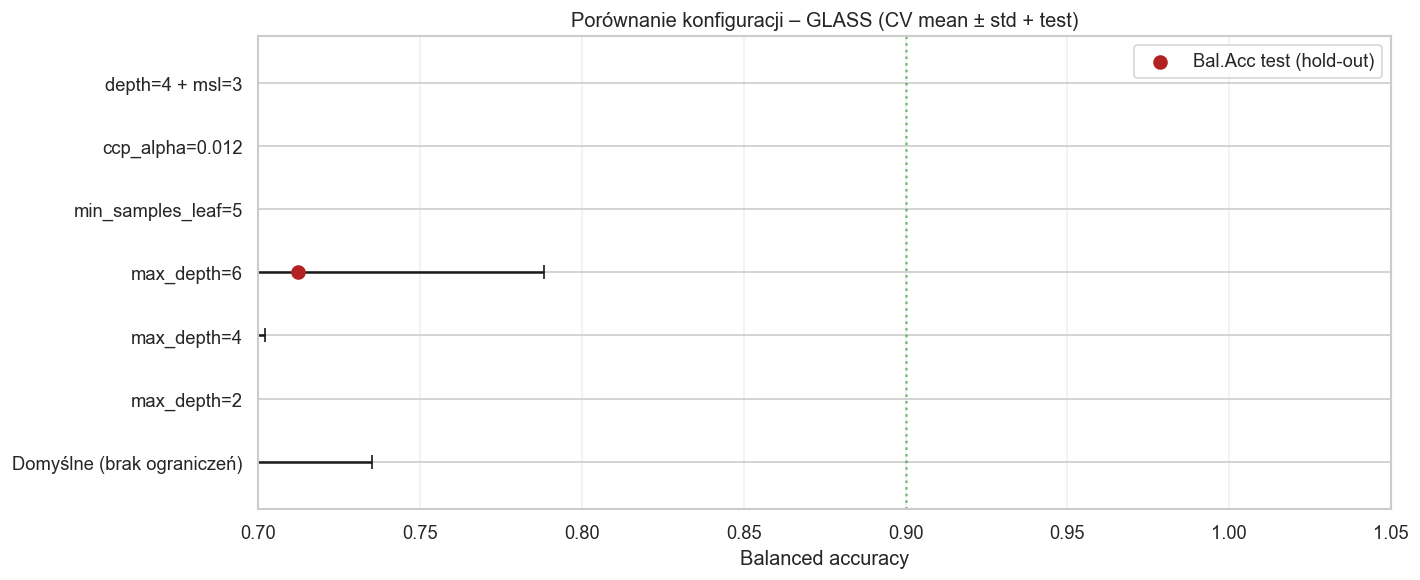

In [55]:
# Wykres podsumowujący GLASS
fig, ax = plt.subplots(figsize=(12, 5))
y_pos = np.arange(len(sum_df))

bars = ax.barh(y_pos, sum_df['CV mean'],
               xerr=sum_df['CV std'], capsize=4,
               color='steelblue')
ax.scatter(sum_df['Bal.Acc Test'], y_pos, color='firebrick',
           zorder=5, s=60, label='Bal.Acc test (hold-out)')
ax.set_yticks(y_pos)
ax.set_yticklabels(sum_df['Konfiguracja'])
ax.set_xlabel('Balanced accuracy')
ax.set_title('Porównanie konfiguracji – GLASS (CV mean ± std + test)')
ax.axvline(0.9, color='green', linestyle=':', alpha=0.5)
ax.legend()
ax.set_xlim(0.7, 1.05)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Granica decyzyjna – GLASS (PCA 2D)

Redukujemy dane do 2 wymiarów (PCA) i rysujemy granicę decyzyjną dla różnych `max_depth`.

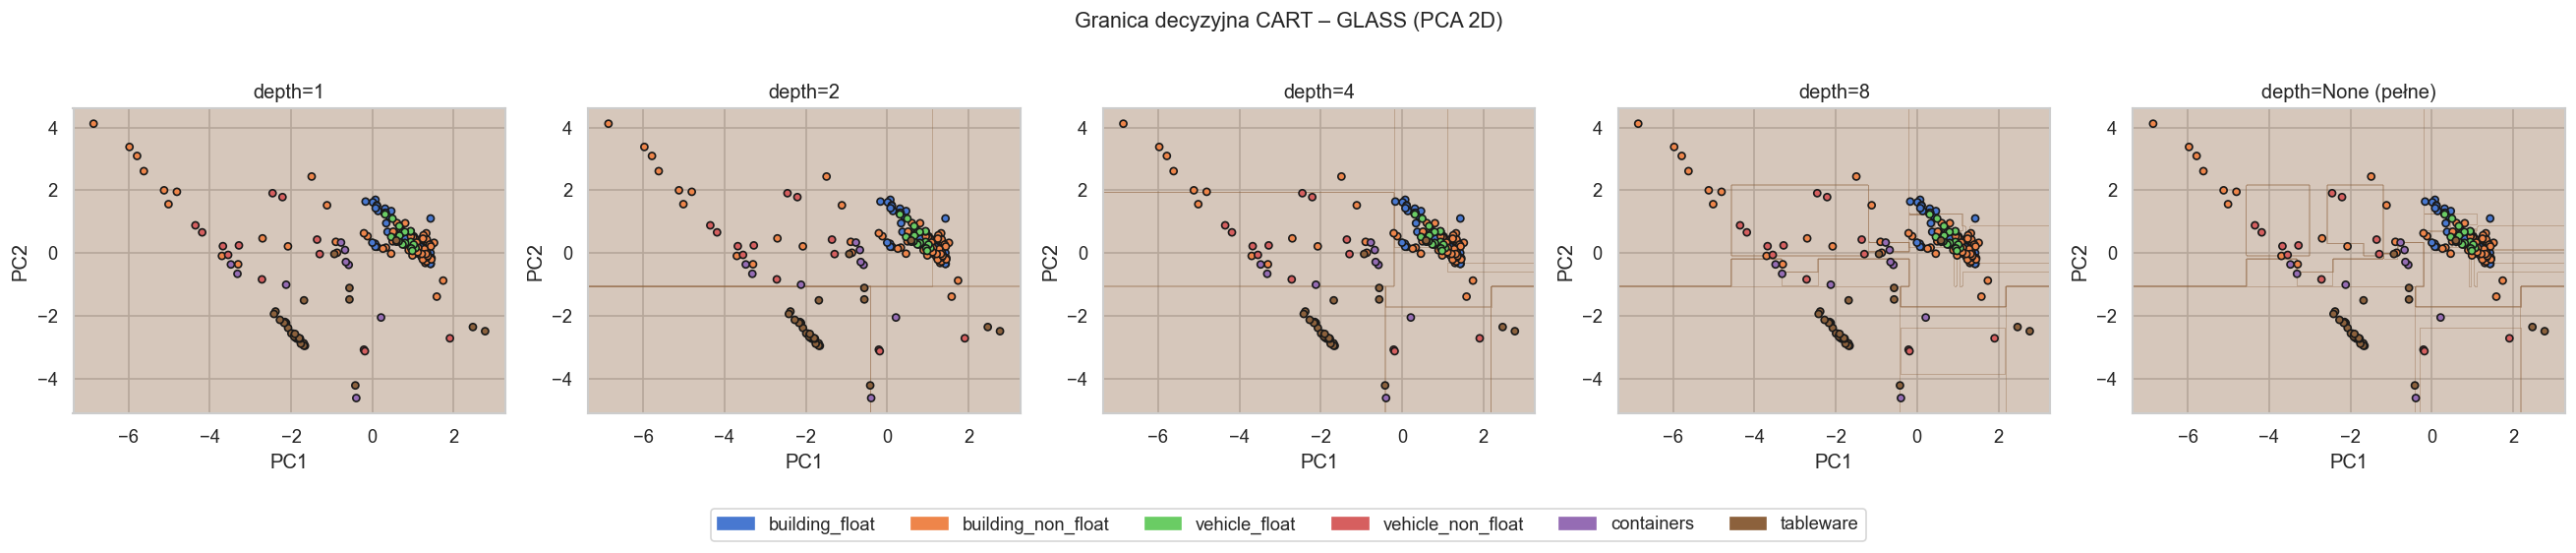

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_glass_2d = pca.fit_transform(X_glass)

depths_vis = [1, 2, 4, 8, None]
titles = ['depth=1', 'depth=2', 'depth=4', 'depth=8', 'depth=None (pełne)']

x_min, x_max = X_glass_2d[:, 0].min() - 0.5, X_glass_2d[:, 0].max() + 0.5
y_min, y_max = X_glass_2d[:, 1].min() - 0.5, X_glass_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

palette6 = ['C0','C1','C2','C3','C4','C5']
class_vals = sorted(y_glass.unique())
cmap_bg = ListedColormap([c + '55' for c in palette6])
cmap_pt = ListedColormap(palette6)
val_to_idx = {v: ii for ii, v in enumerate(class_vals)}
y_idx = y_glass.map(val_to_idx).values

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, d, title in zip(axes, depths_vis, titles):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_glass_2d, y_idx)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg, levels=np.arange(-0.5, 6, 1))
    ax.scatter(X_glass_2d[:, 0], X_glass_2d[:, 1],
               c=y_idx, cmap=cmap_pt, s=18, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

patches = [mpatches.Patch(color=palette6[i], label=target_names_glass[i])
           for i in range(len(class_vals))]
fig.legend(handles=patches, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.12))
fig.suptitle('Granica decyzyjna CART – GLASS (PCA 2D)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


---
## 12. Stabilność modelu – 50 losowych podziałów

Violinplot accuracy i F1 macro dla 4 konfiguracji, 50 random seeds. Szerszy violin = większa wariancja = mniej stabilny model.

In [59]:
N_RUNS = 50
seeds  = range(N_RUNS)

stability_configs = {
    'Brak ogranicz.\n(None)': dict(),
    'max_depth=4':            dict(max_depth=4),
    'max_depth=4\n+msl=5':   dict(max_depth=4, min_samples_leaf=5),
    'ccp_alpha=0.01':         dict(ccp_alpha=0.01),
}

# GLASS – zbieramy acc i f1_macro
stab_glass = {k: {'acc': [], 'f1': []} for k in stability_configs}
# PCB – zbieramy acc i f1 dla klasy bankrut
stab_pcb   = {k: {'acc': [], 'f1': []} for k in stability_configs}

for seed in seeds:
    Xtrg, Xteg, ytrg, yteg = train_test_split(
        X_glass, y_glass, test_size=0.25, stratify=y_glass)
    Xtrp, Xtep, ytrp, ytep = train_test_split(
        X_pcb_imp, y_pcb_s, test_size=0.25, stratify=y_pcb_s)
    for cfg_name, params in stability_configs.items():
        # GLASS
        clg = DecisionTreeClassifier(**params)
        clg.fit(Xtrg, ytrg); yp = clg.predict(Xteg)
        stab_glass[cfg_name]['acc'].append(balanced_accuracy_score(yteg, yp))
        stab_glass[cfg_name]['f1'].append(f1_score(yteg, yp, average='macro'))
        # PCB
        clp = DecisionTreeClassifier(**params, class_weight='balanced')
        clp.fit(Xtrp, ytrp); yp = clp.predict(Xtep)
        stab_pcb[cfg_name]['acc'].append(balanced_accuracy_score(ytep, yp))
        stab_pcb[cfg_name]['f1'].append(f1_score(ytep, yp, average='macro'))

Zbieranie danych zakończone.


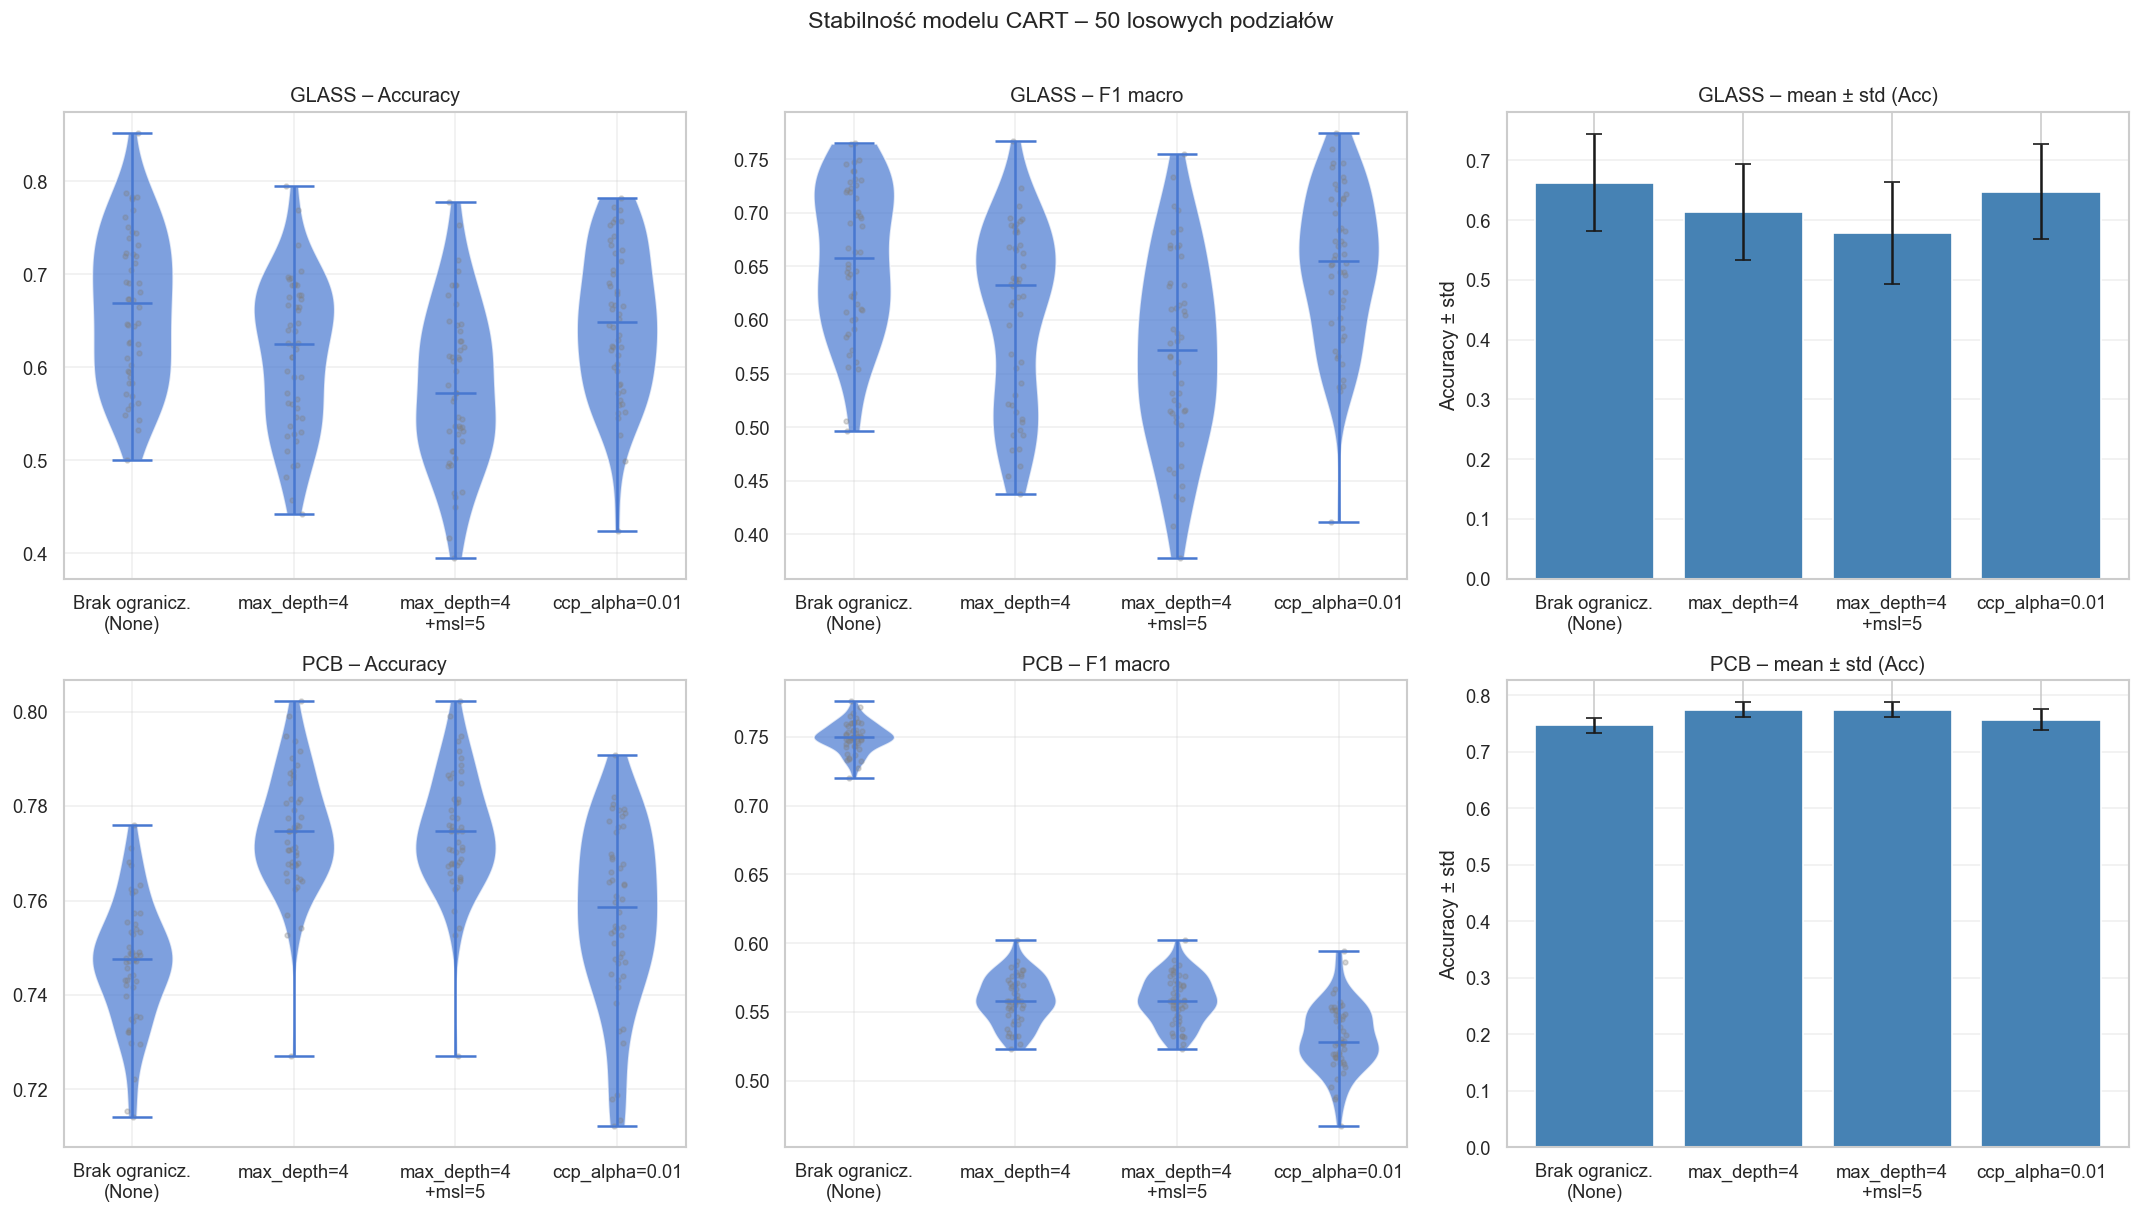

In [60]:
cfg_labels = list(stability_configs.keys())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def violin_row(ax_viol, ax_f1, ax_bar, data_dict, title_prefix):
    data_acc = [data_dict[k]['acc'] for k in cfg_labels]
    data_f1  = [data_dict[k]['f1']  for k in cfg_labels]

    vp = ax_viol.violinplot(data_acc, positions=range(len(cfg_labels)), showmedians=True)
    for pc in vp['bodies']: pc.set_alpha(0.7)
    for jj, d in enumerate(data_acc):
        ax_viol.scatter(np.full(len(d), jj) + np.random.uniform(-0.05,0.05,len(d)),
                        d, alpha=0.3, s=8, color='gray')
    ax_viol.set_xticks(range(len(cfg_labels)))
    ax_viol.set_xticklabels(cfg_labels)
    ax_viol.set_title(f'{title_prefix} – Accuracy')
    ax_viol.grid(True, alpha=0.3)

    vp2 = ax_f1.violinplot(data_f1, positions=range(len(cfg_labels)), showmedians=True)
    for pc in vp2['bodies']: pc.set_alpha(0.7)
    for jj, d in enumerate(data_f1):
        ax_f1.scatter(np.full(len(d), jj) + np.random.uniform(-0.05,0.05,len(d)),
                      d, alpha=0.3, s=8, color='gray')
    ax_f1.set_xticks(range(len(cfg_labels)))
    ax_f1.set_xticklabels(cfg_labels)
    ax_f1.set_title(f'{title_prefix} – F1 macro')
    ax_f1.grid(True, alpha=0.3)

    means = [np.mean(d) for d in data_acc]
    stds  = [np.std(d)  for d in data_acc]
    ax_bar.bar(range(len(cfg_labels)), means, yerr=stds, capsize=5,
               color='steelblue')
    ax_bar.set_xticks(range(len(cfg_labels)))
    ax_bar.set_xticklabels(cfg_labels)
    ax_bar.set_ylabel('Accuracy ± std')
    ax_bar.set_title(f'{title_prefix} – mean ± std (Acc)')
    ax_bar.grid(True, alpha=0.3, axis='y')

violin_row(axes[0,0], axes[0,1], axes[0,2], stab_glass, 'GLASS')
violin_row(axes[1,0], axes[1,1], axes[1,2], stab_pcb,   'PCB')

plt.suptitle('Stabilność modelu CART – 50 losowych podziałów', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
